<a href="https://colab.research.google.com/github/Thilan67/PlayerTrackingInSports/blob/main/ProgrammingAssignment2_DTS2409.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi

Wed Jun 24 08:43:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   56C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Install necessary libraries
!pip install ultralytics roboflow opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 97.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 140.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18


In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [ ]:
from roboflow import Roboflow
from google.colab import userdata
from IPython.display import Image

In [ ]:
from roboflow import Roboflow
from roboflow import Roboflow
from google.colab import userdata

api_key = userdata.get("ROBOFLOW_API_KEY")

rf = Roboflow(api_key=api_key)
project = rf.workspace("aiwiththilan").project("detectplayers-0hxtm")
version = project.version(3)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to DetectPlayers-3 in yolov8:: 100%|██████████| 310/310 [00:00<00:00, 4139.69it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
import os
import yaml

# Fix the paths in your data.yaml
yaml_path = f'{dataset.location}/data.yaml'

with open(yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

print("Before fixing:")
print(f"Train: {data_config['train']}")
print(f"Val: {data_config['val']}")

# Update to correct paths for YOUR dataset
data_config['train'] = f'{dataset.location}/train/images'
data_config['val'] = f'{dataset.location}/valid/images'

# Only include test if the directory exists
test_path = f'{dataset.location}/test/images'
if os.path.exists(test_path):
    data_config['test'] = test_path
elif 'test' in data_config:
    del data_config['test']

# Save the corrected data.yaml
with open(yaml_path, 'w') as f:
    yaml.dump(data_config, f)

print("\nAfter fixing:")
print(f"Train: {data_config['train']}")
print(f"Val: {data_config['val']}")
print(f"Test: {data_config.get('test', 'Not included')}")

# Verify the corrected paths exist
print("\n✅ Corrected path verification:")
print(f"Train path exists: {os.path.exists(data_config['train'])}")
print(f"Val path exists: {os.path.exists(data_config['val'])}")

Before fixing:
Train: ../train/images
Val: ../valid/images

After fixing:
Train: /content/DetectPlayers-3/train/images
Val: /content/DetectPlayers-3/valid/images
Test: /content/DetectPlayers-3/test/images

✅ Corrected path verification:
Train path exists: True
Val path exists: True


In [ ]:
%cd {HOME}

# Use smaller model and resolution
!yolo task=detect mode=train model=yolov8s.pt data={dataset.location}/data.yaml batch=16 epochs=50 imgsz=640 plots=True

/content
Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/DetectPlayers-3/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True,

/content

🎯 Confusion Matrix:


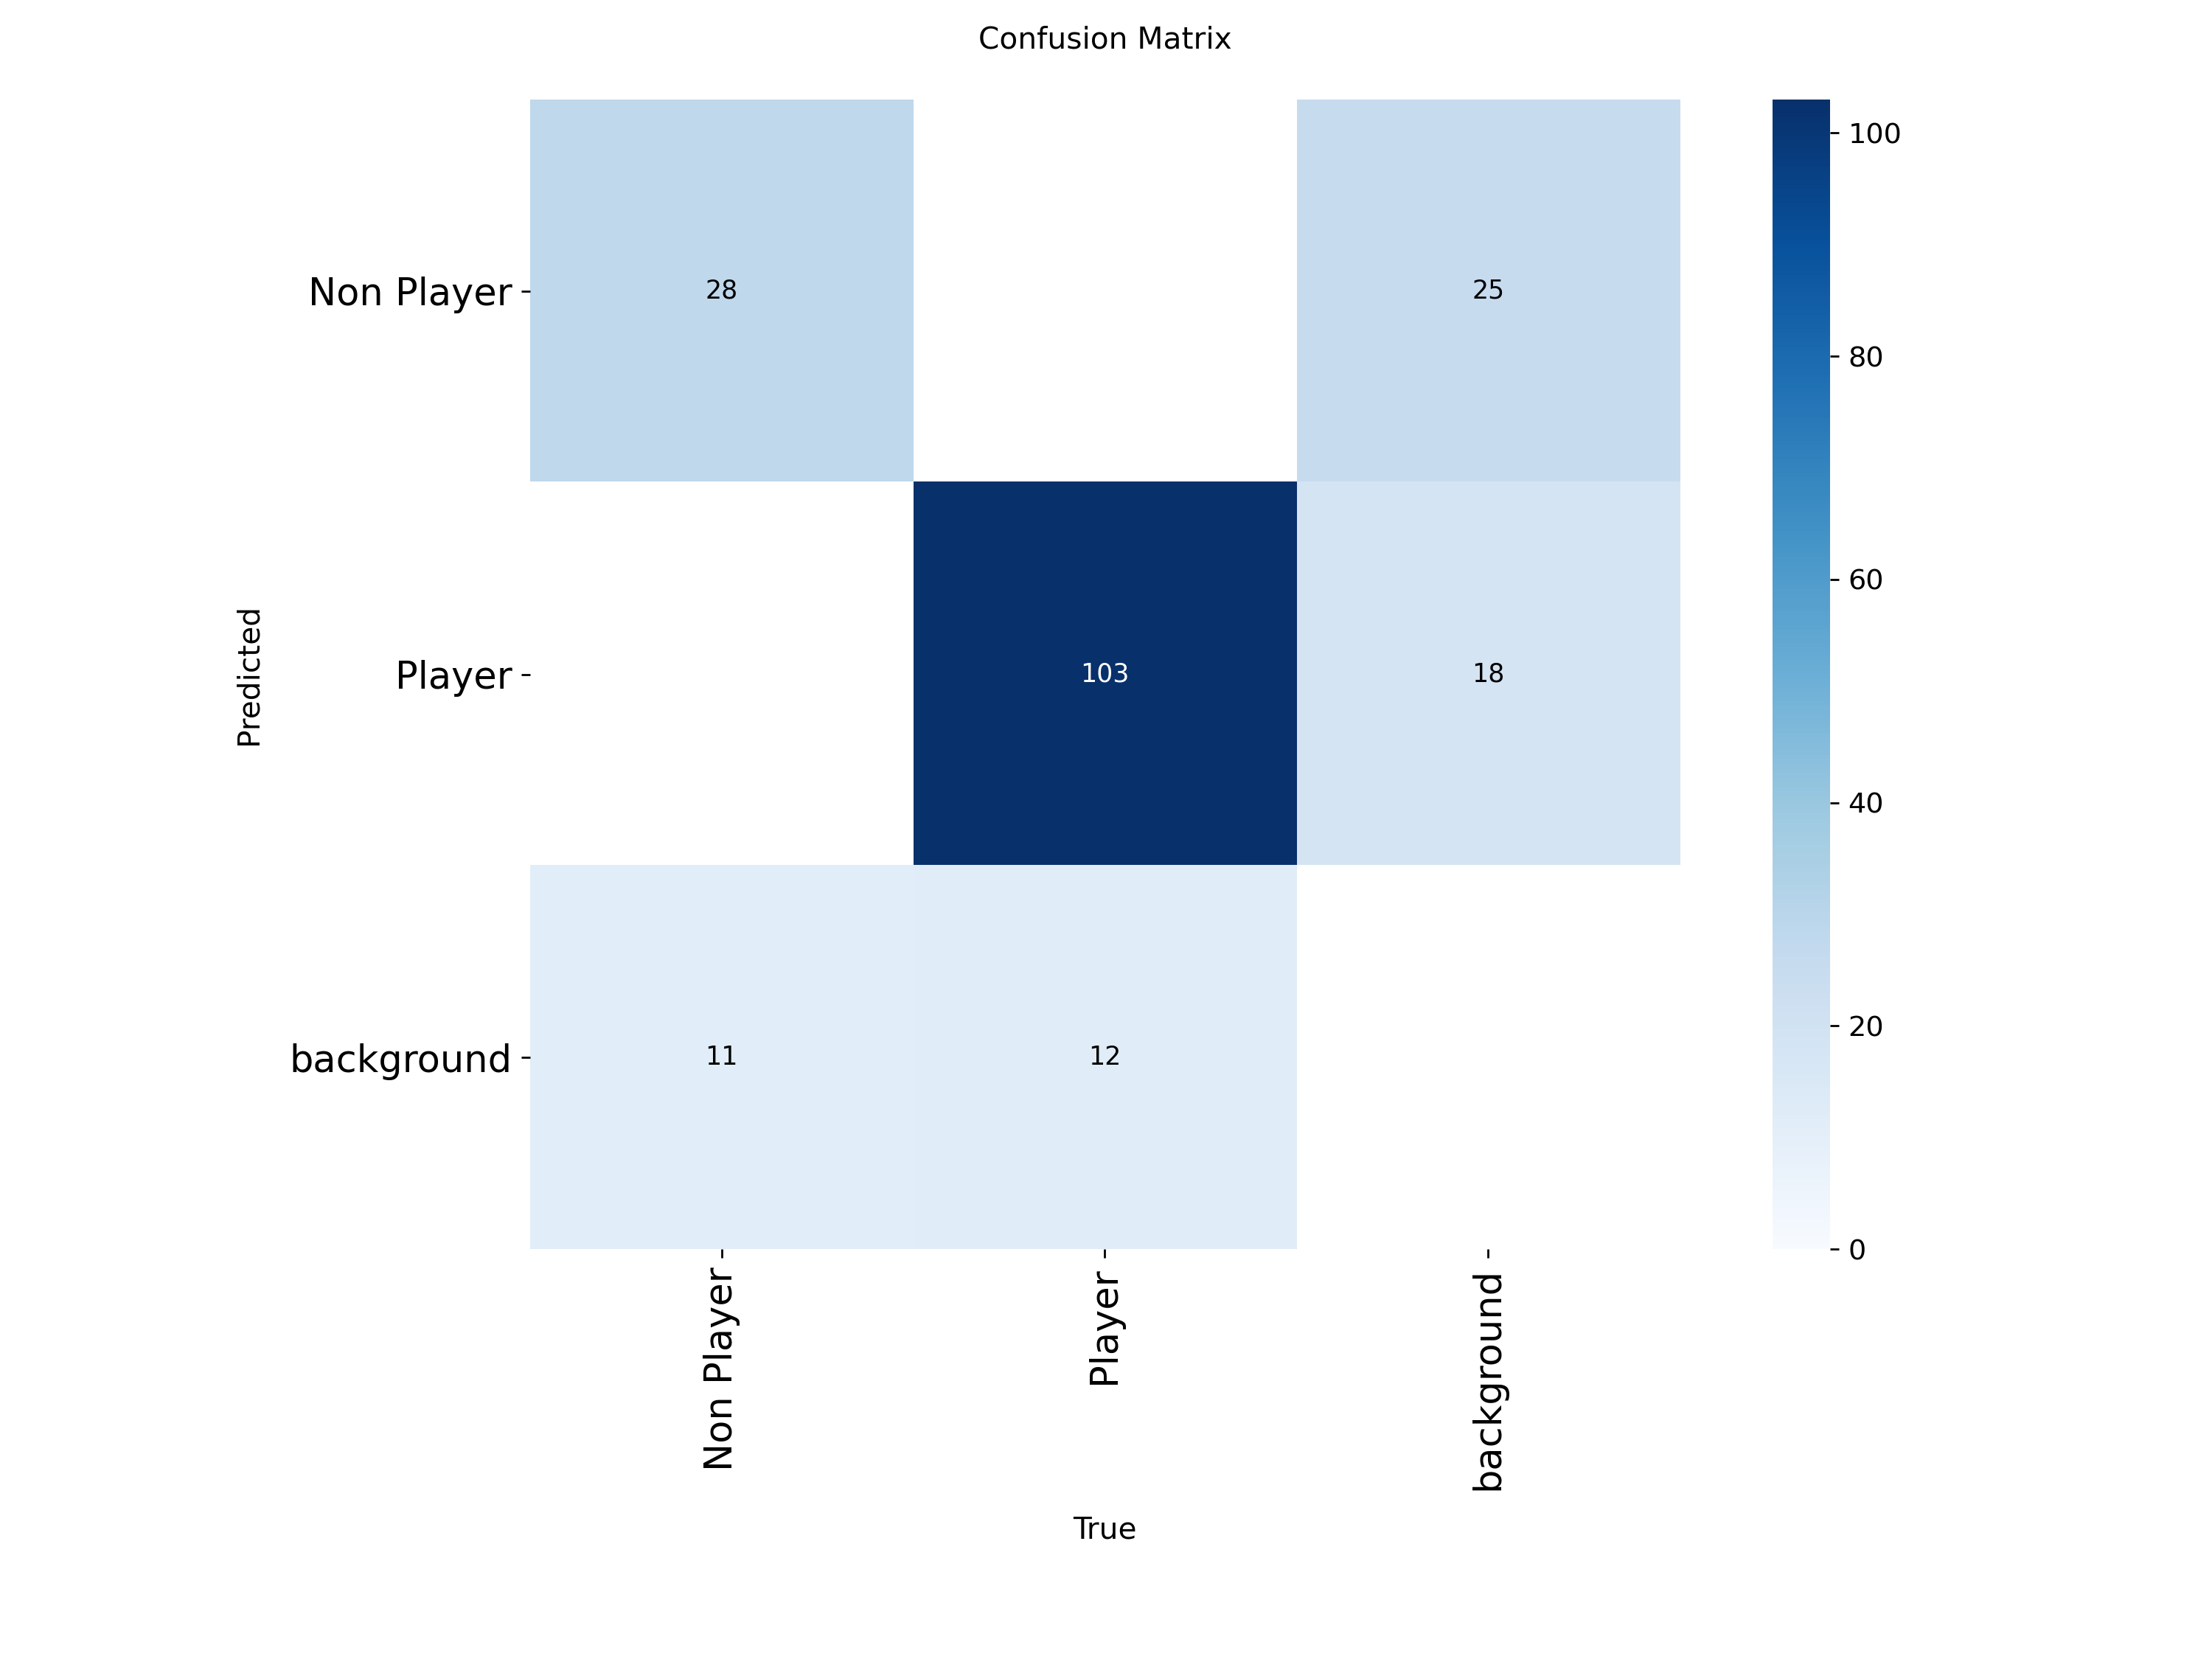


📈 Training Metrics:


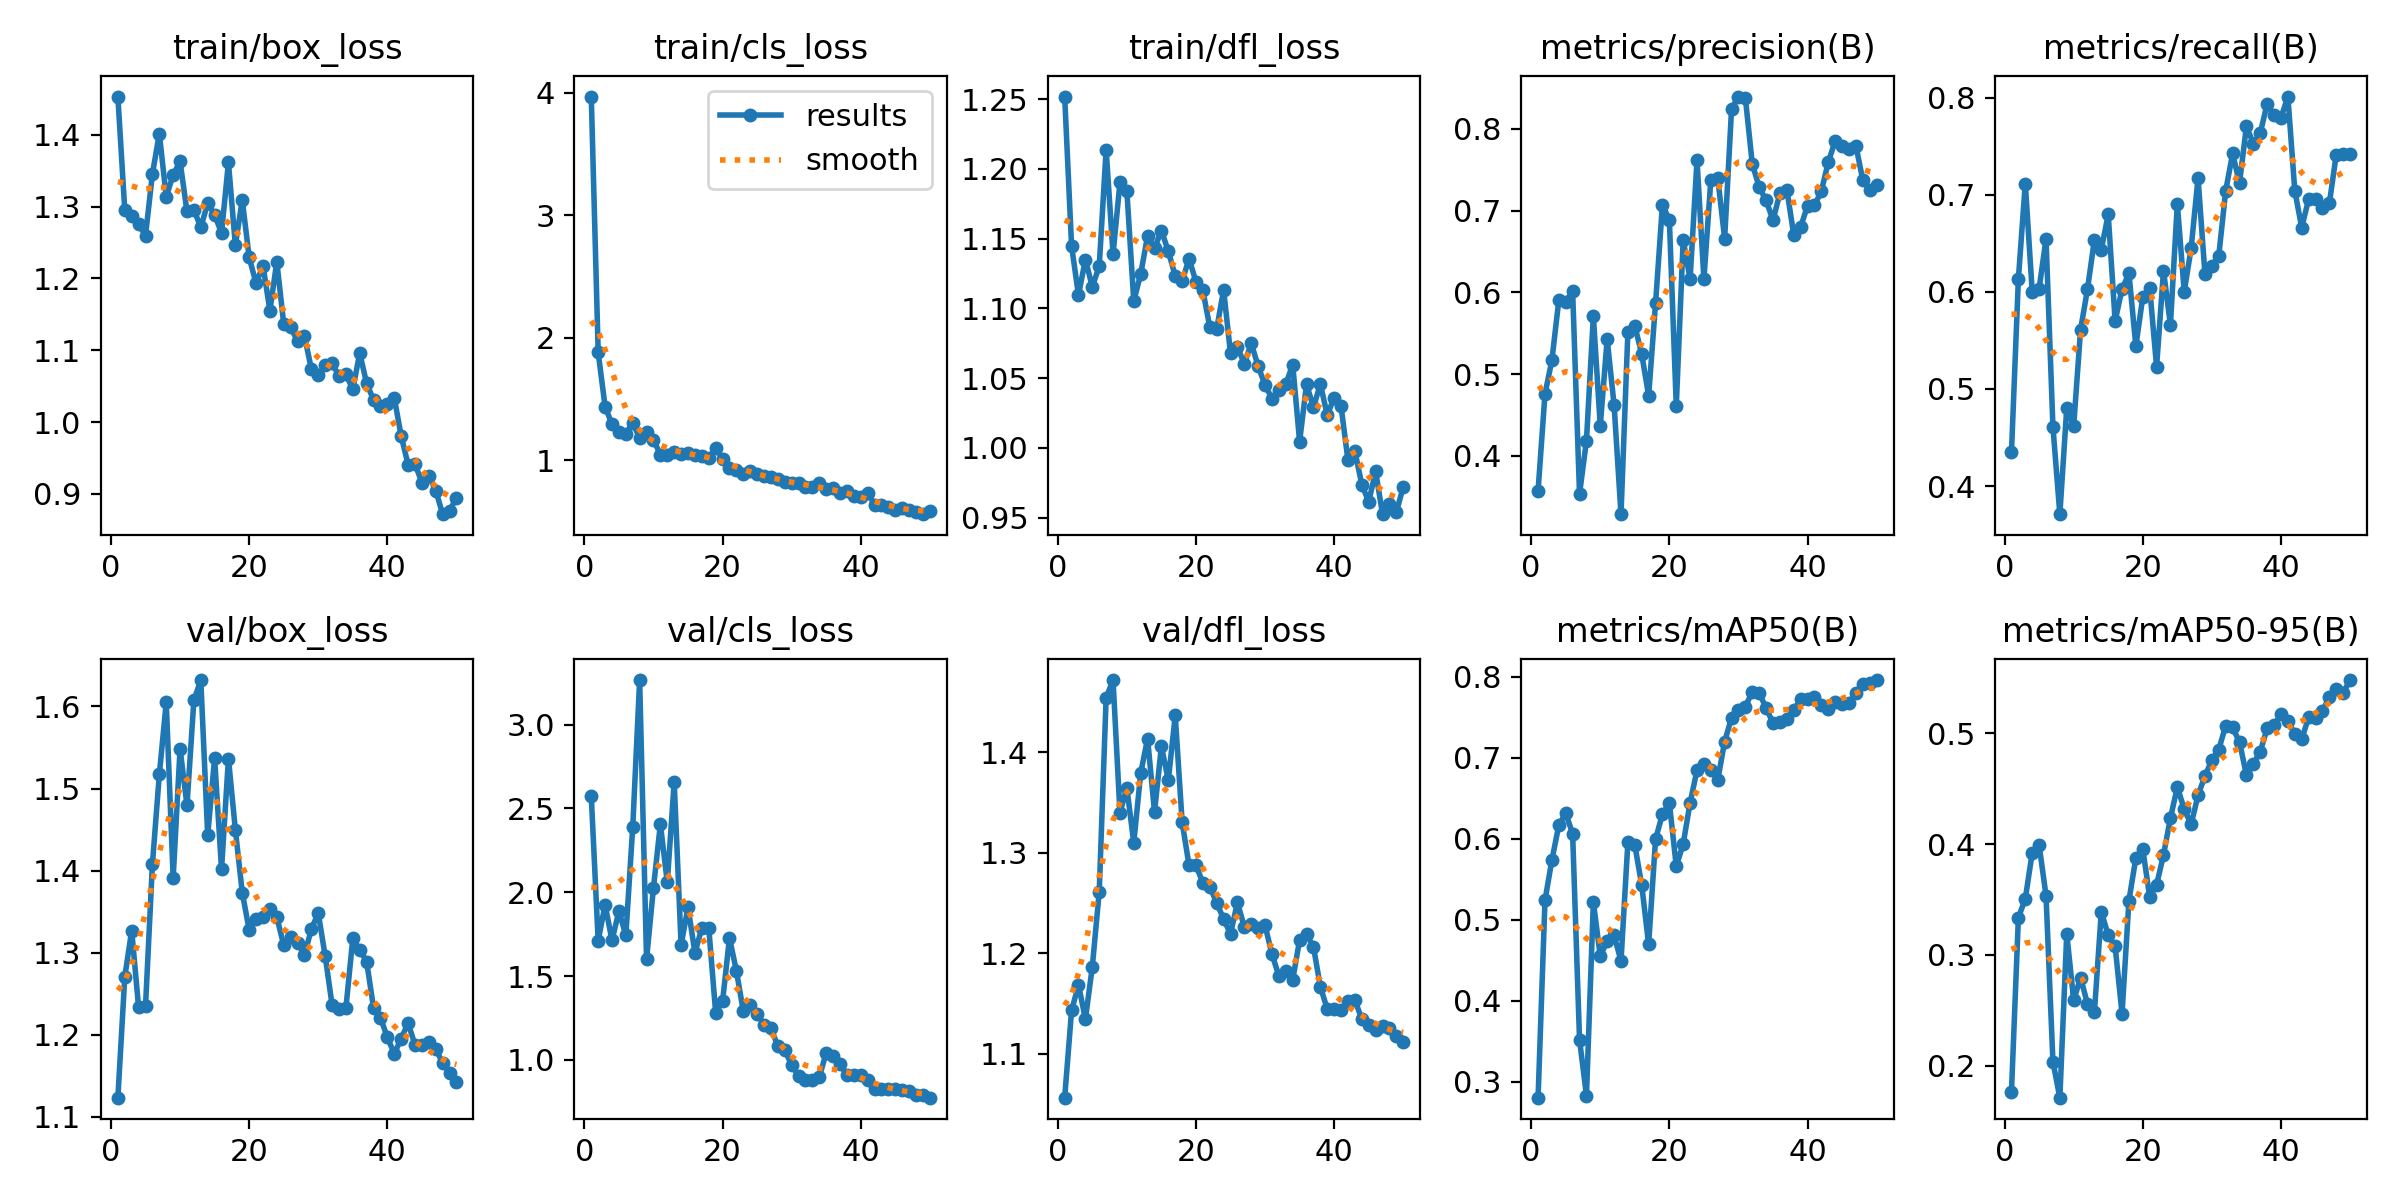


🔍 Sample Predictions:


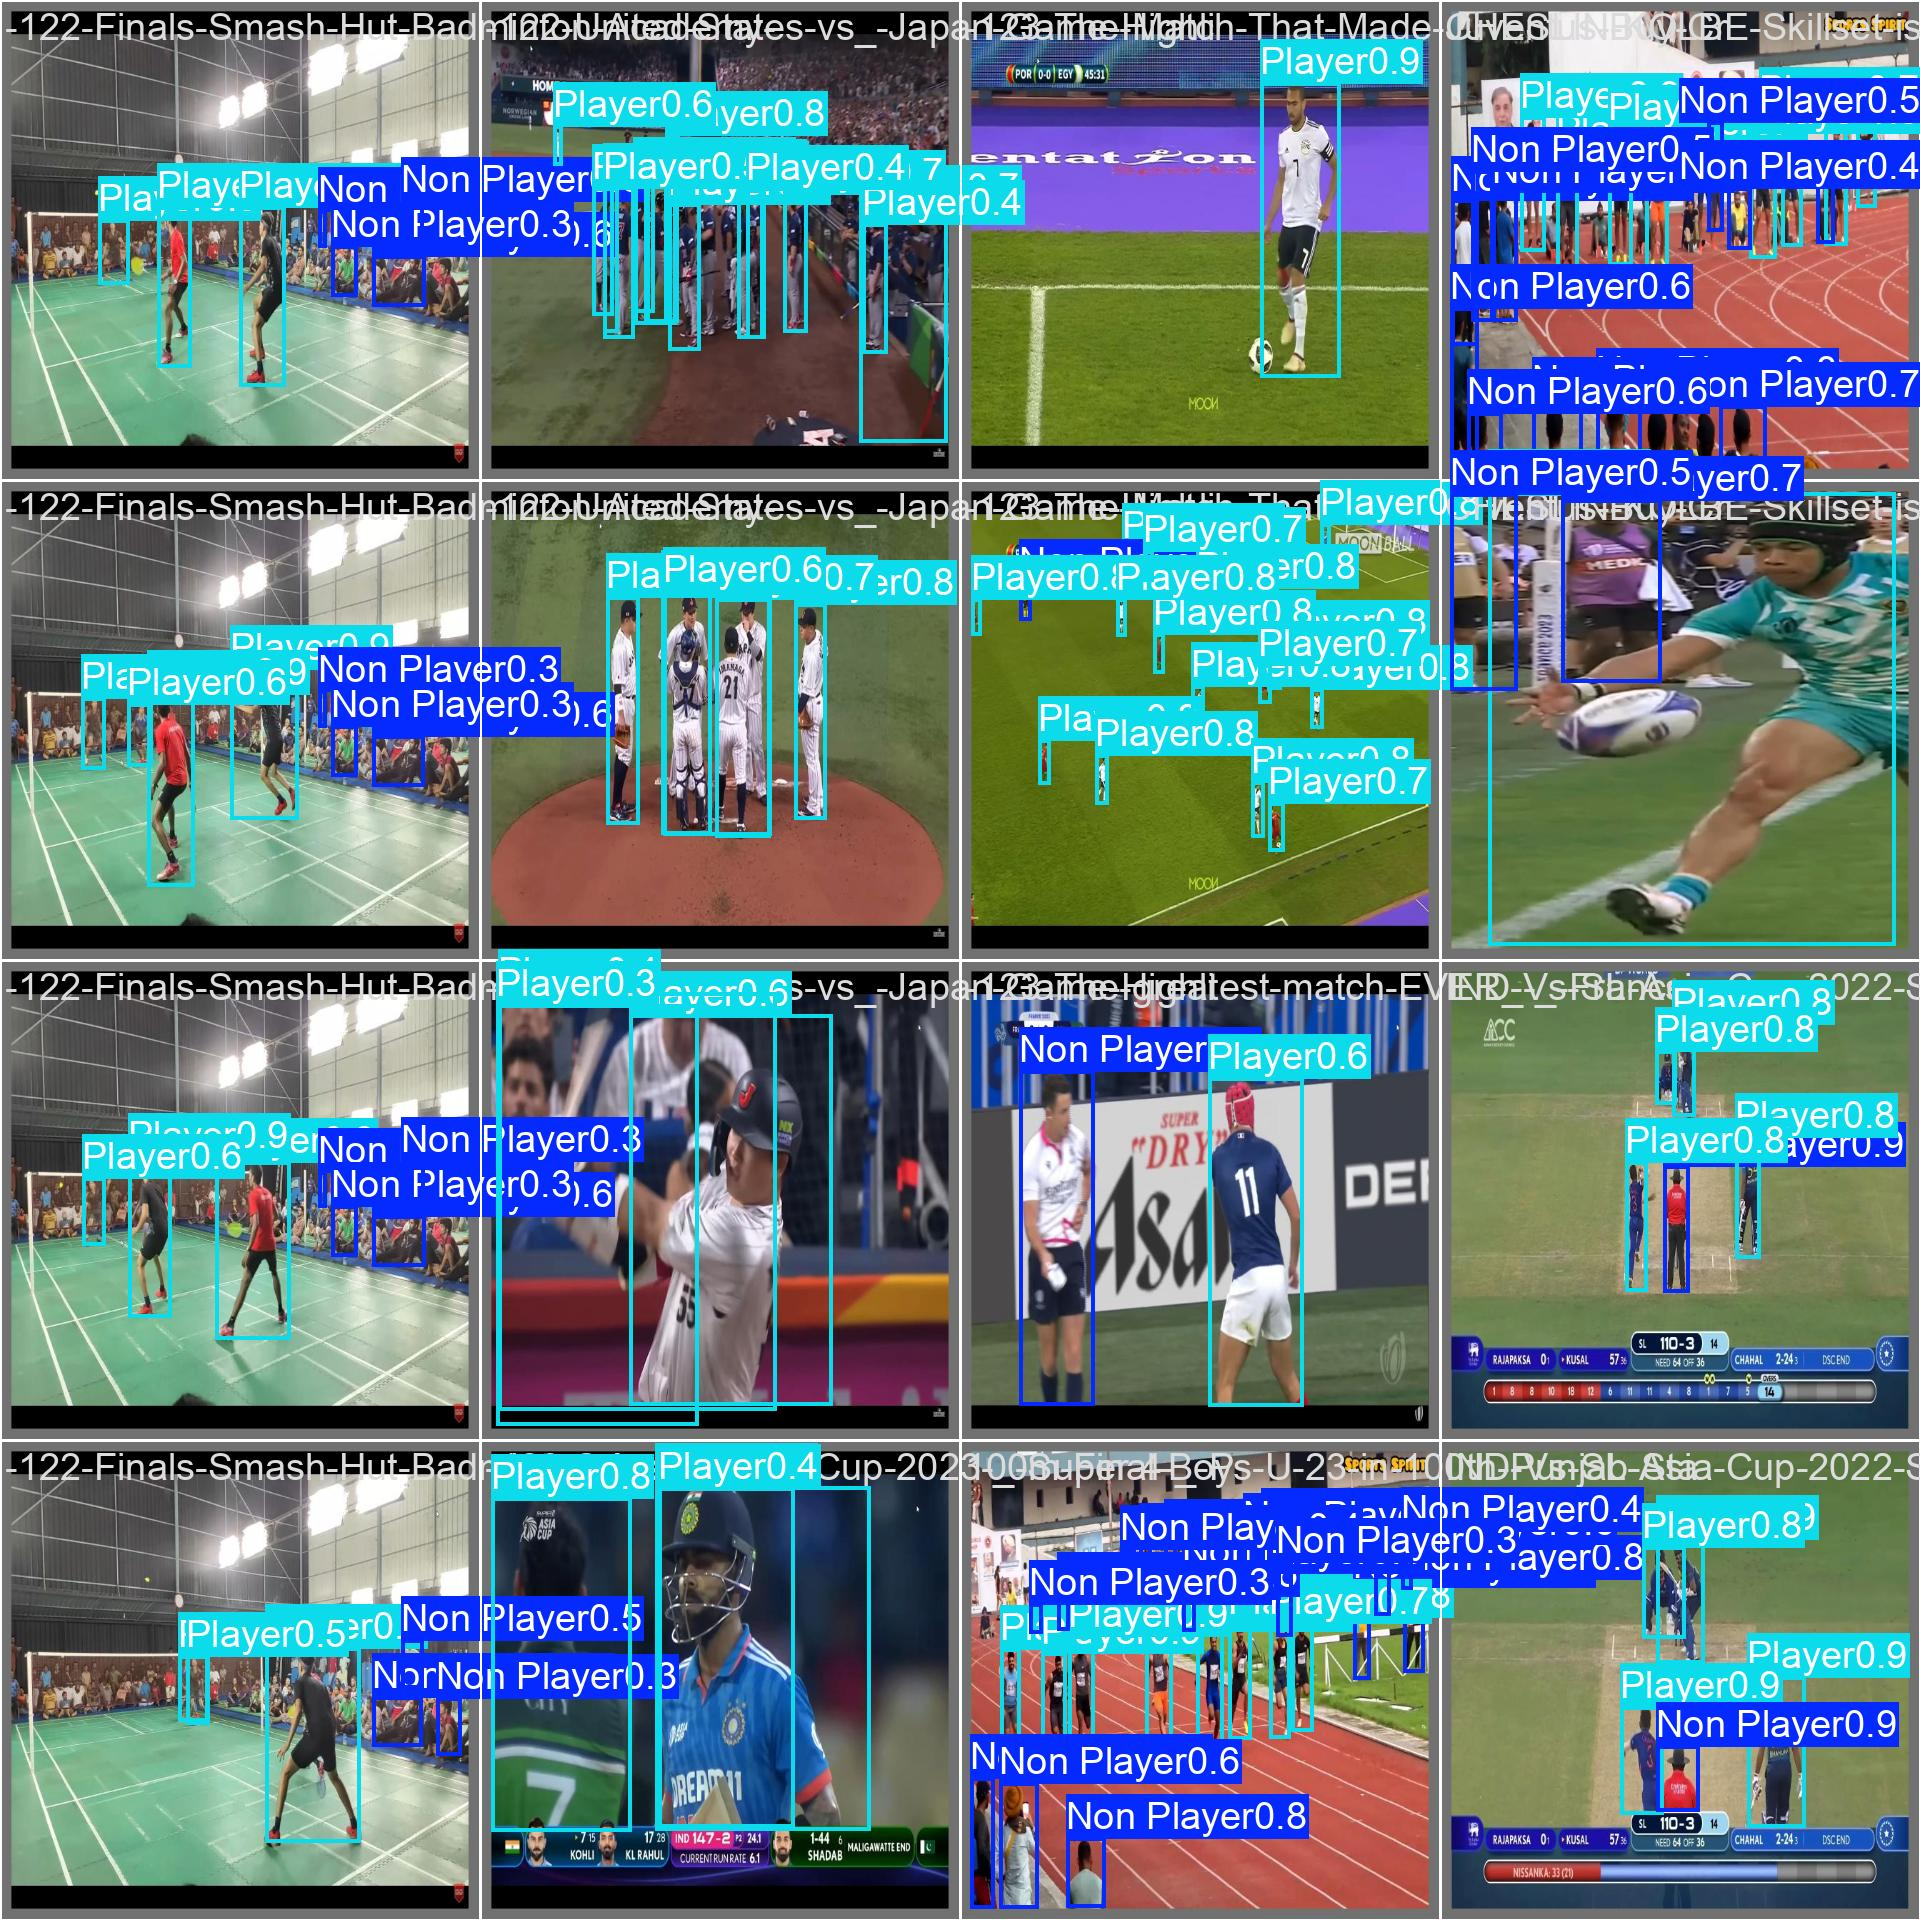


📊 Label Distribution:


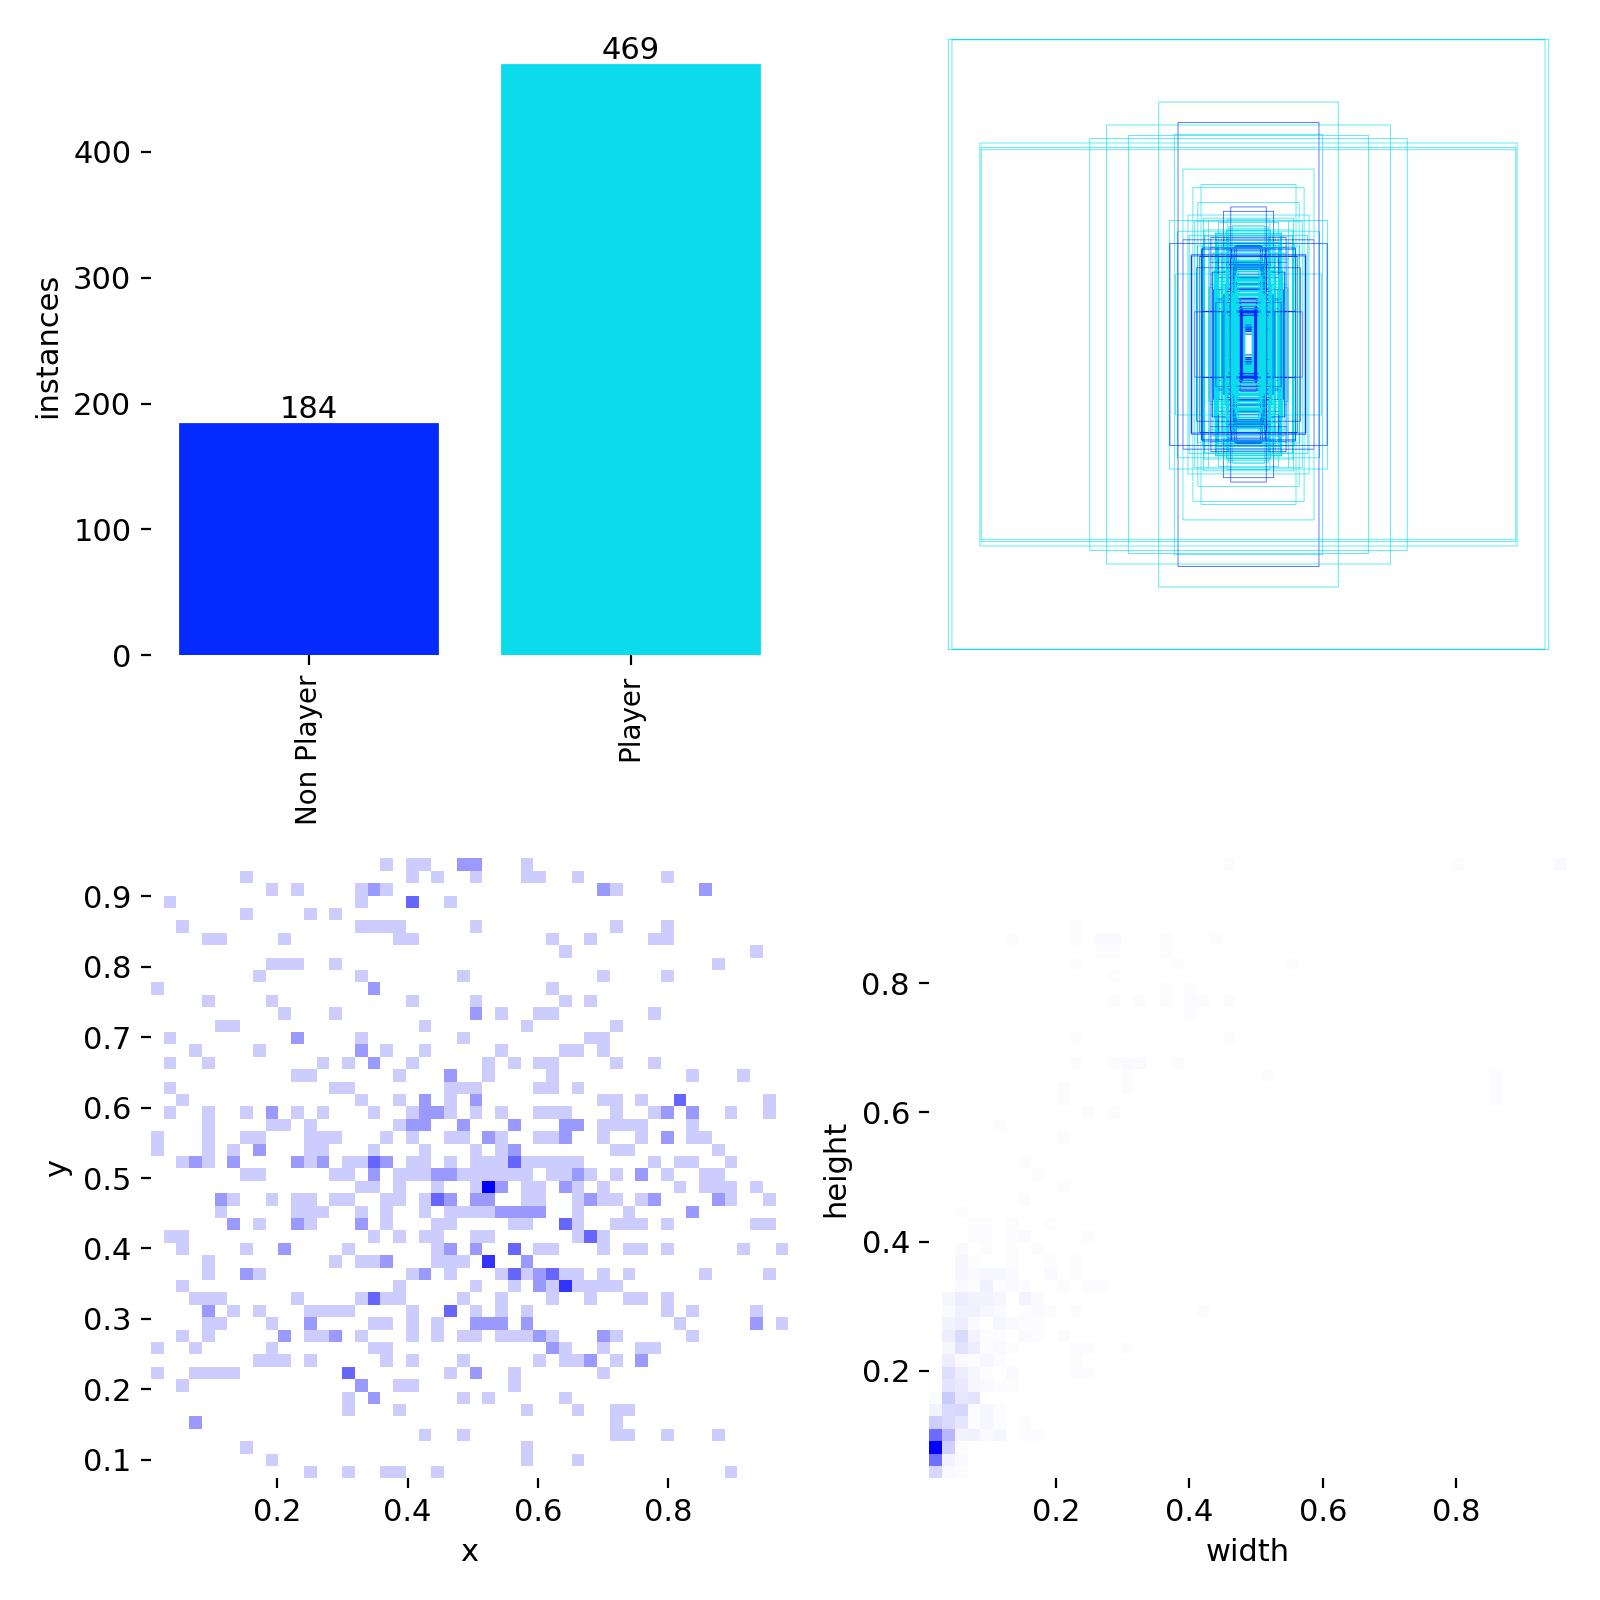

In [ ]:
%cd {HOME}

from IPython.display import Image
import os

# Display all results after training completes
results_files = {
    'confusion_matrix.png': '🎯 Confusion Matrix',
    'results.png': '📈 Training Metrics',
    'val_batch0_pred.jpg': '🔍 Sample Predictions',
    'labels.jpg': '📊 Label Distribution'
}

for file, description in results_files.items():
    file_path = f'runs/detect/train/{file}'
    if os.path.exists(file_path):
        print(f"\n{description}:")
        display(Image(filename=file_path, width=600))
    else:
        print(f"❌ {file} not found yet")

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs

image 1/30 /content/DetectPlayers-3/valid/images/-122-Finals-Smash-Hut-Badminton-Academy-Men-Doubles-Tournament-SIDARTH_T-DHILEPAN-vs-SHIJAS-JAISON-YouTube-Google-Chrome-2025-09-19-12-39-53_mp4-0000_jpg.rf.960bef4e4e824128ccd5b7f5d5831554.jpg: 640x640 1 Non Player, 3 Players, 16.3ms
image 2/30 /content/DetectPlayers-3/valid/images/-122-Finals-Smash-Hut-Badminton-Academy-Men-Doubles-Tournament-SIDARTH_T-DHILEPAN-vs-SHIJAS-JAISON-YouTube-Google-Chrome-2025-09-19-12-39-53_mp4-0001_jpg.rf.86722faa070162ccff63103b800424bb.jpg: 640x640 1 Non Player, 3 Players, 16.2ms
image 3/30 /content/DetectPlayers-3/valid/images/-122-Finals-Smash-Hut-Badminton-Academy-Men-Doubles-Tournament-SIDARTH_T-DHILEPAN-vs-SHIJAS-JAISON-YouTube-Google-Chrome-2025-09-19-12-39-53_mp4-0003_jpg.rf.96fb23f49b68ad5ad8eb40a45c67ef2a.jpg: 640x640 1 Non Player, 

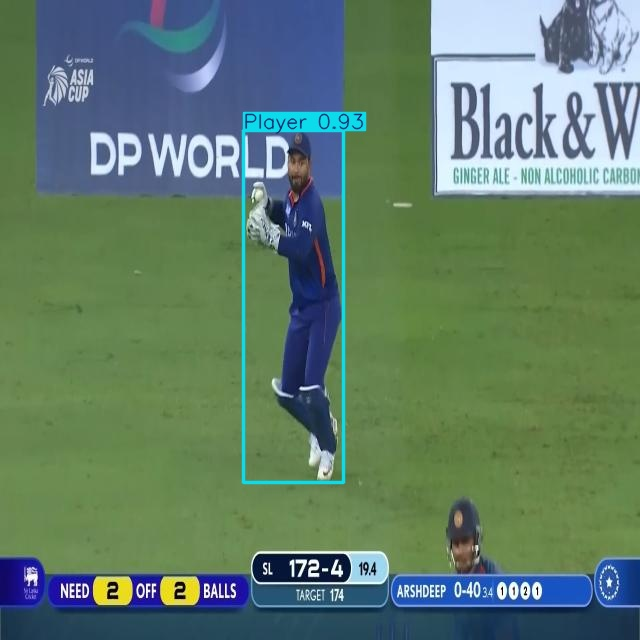

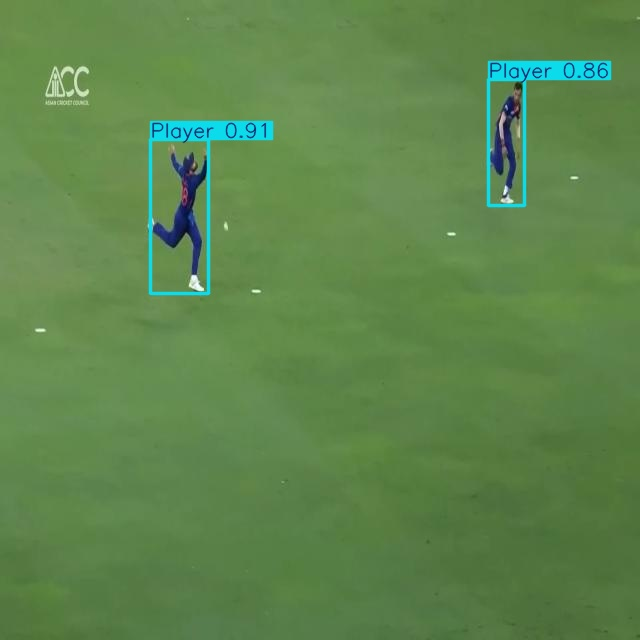

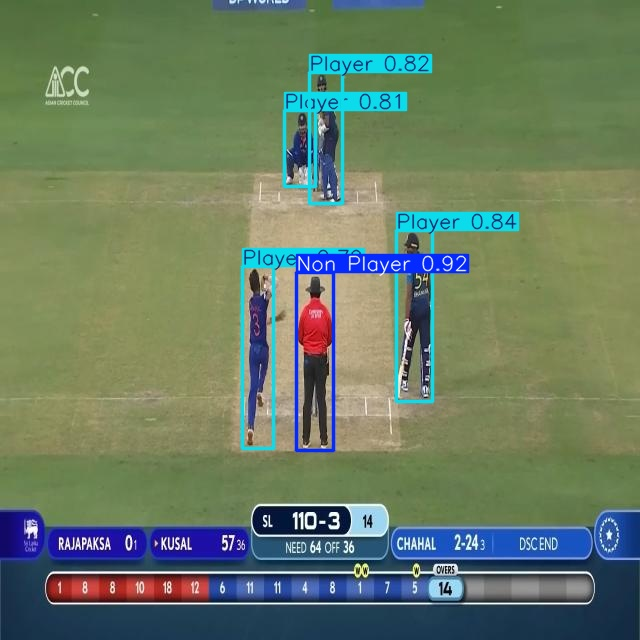

In [ ]:
# Test on validation images
!yolo task=detect mode=predict model=runs/detect/train/weights/best.pt source={dataset.location}/valid/images save=True conf=0.5

# Display predictions
from IPython.display import Image
import glob

print("🔍 Sample Predictions on Validation Set:")
predicted_images = glob.glob('runs/detect/predict*/**.jpg')[:3]
for img_path in predicted_images:
    display(Image(filename=img_path, width=500))

In [ ]:
# Get detailed performance metrics
!yolo task=detect mode=val model=runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1498.7±513.4 MB/s, size: 31.6 KB)
val: Scanning /content/DetectPlayers-3/valid/labels.cache... 30 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 30/30 4.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.7it/s 0.7s
                   all         30        154      0.732      0.738      0.796      0.548
            Non Player         14         39      0.584       0.59      0.654      0.441
                Player         30        115      0.879      0.887      0.938      0.655
Speed: 3.7ms preprocess, 11.1ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /content/runs/detect/val
💡 Learn more at https://docs.ultralytics.com/modes/val


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

In [ ]:
# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# Read the training results
results_csv = 'runs/detect/train/results.csv'
results_df = pd.read_csv(results_csv)

print("📊 Training Results Summary:")
print(results_df[['epoch', 'train/box_loss', 'val/box_loss', 'metrics/precision(B)',
                   'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)']].tail(10))

📊 Training Results Summary:
    epoch  train/box_loss  val/box_loss  metrics/precision(B)  \
40     41         1.03357       1.17670               0.70634   
41     42         0.98051       1.19526               0.72409   
42     43         0.94058       1.21402               0.75940   
43     44         0.94161       1.18742               0.78533   
44     45         0.91560       1.18723               0.77856   
45     46         0.92528       1.19072               0.77583   
46     47         0.90464       1.18296               0.77925   
47     48         0.87169       1.16517               0.73699   
48     49         0.87661       1.15341               0.72573   
49     50         0.89441       1.14177               0.73146   

    metrics/recall(B)  metrics/mAP50(B)  metrics/mAP50-95(B)  
40            0.80115           0.77460              0.51064  
41            0.70424           0.76518              0.49971  
42            0.66621           0.75969              0.49459  
43  

Found columns:
  Box Loss: val/box_loss
  Precision: metrics/precision(B)
  mAP50-95: metrics/mAP50-95(B)


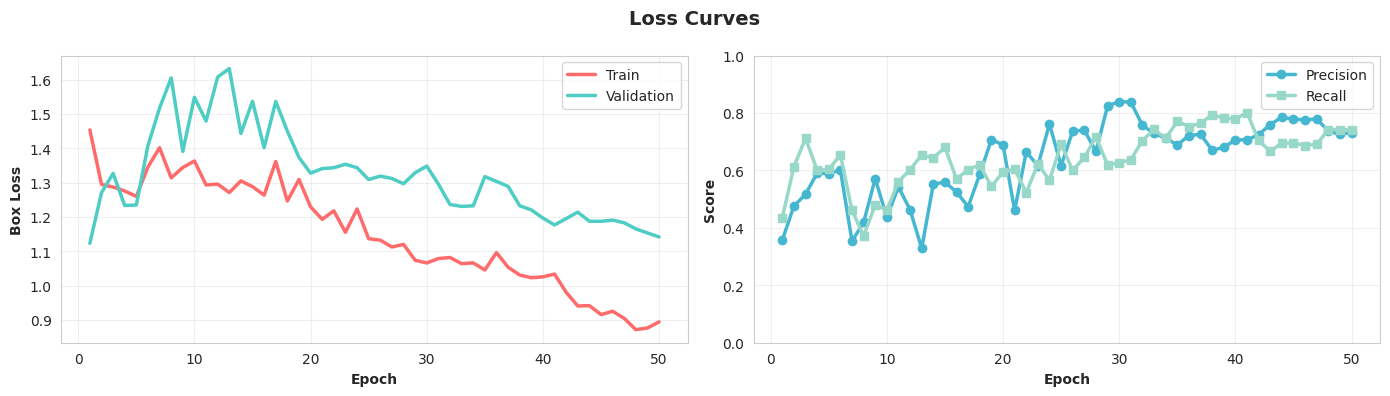


📊 BEST METRICS:
Epoch: 50
Precision: 0.7315
Recall: 0.7415
mAP50-95: 0.5480


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

results_csv = 'runs/detect/train/results.csv'
results_df = pd.read_csv(results_csv)

# Helper function - automatically finds correct column names
def find_column(df, possible_names):
    """Find which column name exists"""
    for name in possible_names:
        if name in df.columns:
            return name
    return None

# Map columns
box_loss_train = find_column(results_df, ['train/box_loss', 'train_loss/box_loss'])
box_loss_val = find_column(results_df, ['val/box_loss', 'val_loss/box_loss'])
precision = find_column(results_df, ['metrics/precision(B)', 'precision'])
recall = find_column(results_df, ['metrics/recall(B)', 'recall'])
map50 = find_column(results_df, ['metrics/mAP50(B)', 'mAP50'])
map50_95 = find_column(results_df, ['metrics/mAP50-95(B)', 'mAP50-95'])
epoch = find_column(results_df, ['epoch', 'Epoch'])

print("Found columns:")
print(f"  Box Loss: {box_loss_val}")
print(f"  Precision: {precision}")
print(f"  mAP50-95: {map50_95}")

# LOSS CURVES
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Loss Curves', fontsize=14, fontweight='bold')

if box_loss_train and box_loss_val:
    axes[0].plot(results_df[epoch], results_df[box_loss_train], label='Train', linewidth=2.5, color='#FF6B6B')
    axes[0].plot(results_df[epoch], results_df[box_loss_val], label='Validation', linewidth=2.5, color='#4ECDC4')
    axes[0].set_xlabel('Epoch', fontweight='bold')
    axes[0].set_ylabel('Box Loss', fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

# METRICS
if precision and recall:
    axes[1].plot(results_df[epoch], results_df[precision], label='Precision', linewidth=2.5, color='#45B7D1', marker='o')
    axes[1].plot(results_df[epoch], results_df[recall], label='Recall', linewidth=2.5, color='#98D8C8', marker='s')
    axes[1].set_xlabel('Epoch', fontweight='bold')
    axes[1].set_ylabel('Score', fontweight='bold')
    axes[1].set_ylim([0, 1])
    axes[1].legend()
    axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('performance_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# SUMMARY
print("\n" + "="*50)
print("📊 BEST METRICS:")
print("="*50)
if map50_95:
    best_idx = results_df[map50_95].idxmax()
    best = results_df.iloc[best_idx]
    print(f"Epoch: {int(best[epoch])}")
    if precision:
        print(f"Precision: {best[precision]:.4f}")
    if recall:
        print(f"Recall: {best[recall]:.4f}")
    if map50_95:
        print(f"mAP50-95: {best[map50_95]:.4f}")
print("="*50)

Saving images5.jpg to images5.jpg
Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs

image 1/1 /content/images5.jpg: 448x640 3 Players, 45.3ms
Speed: 4.8ms preprocess, 45.3ms inference, 16.5ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict-8
💡 Learn more at https://docs.ultralytics.com/modes/predict
Prediction for images5.jpg:


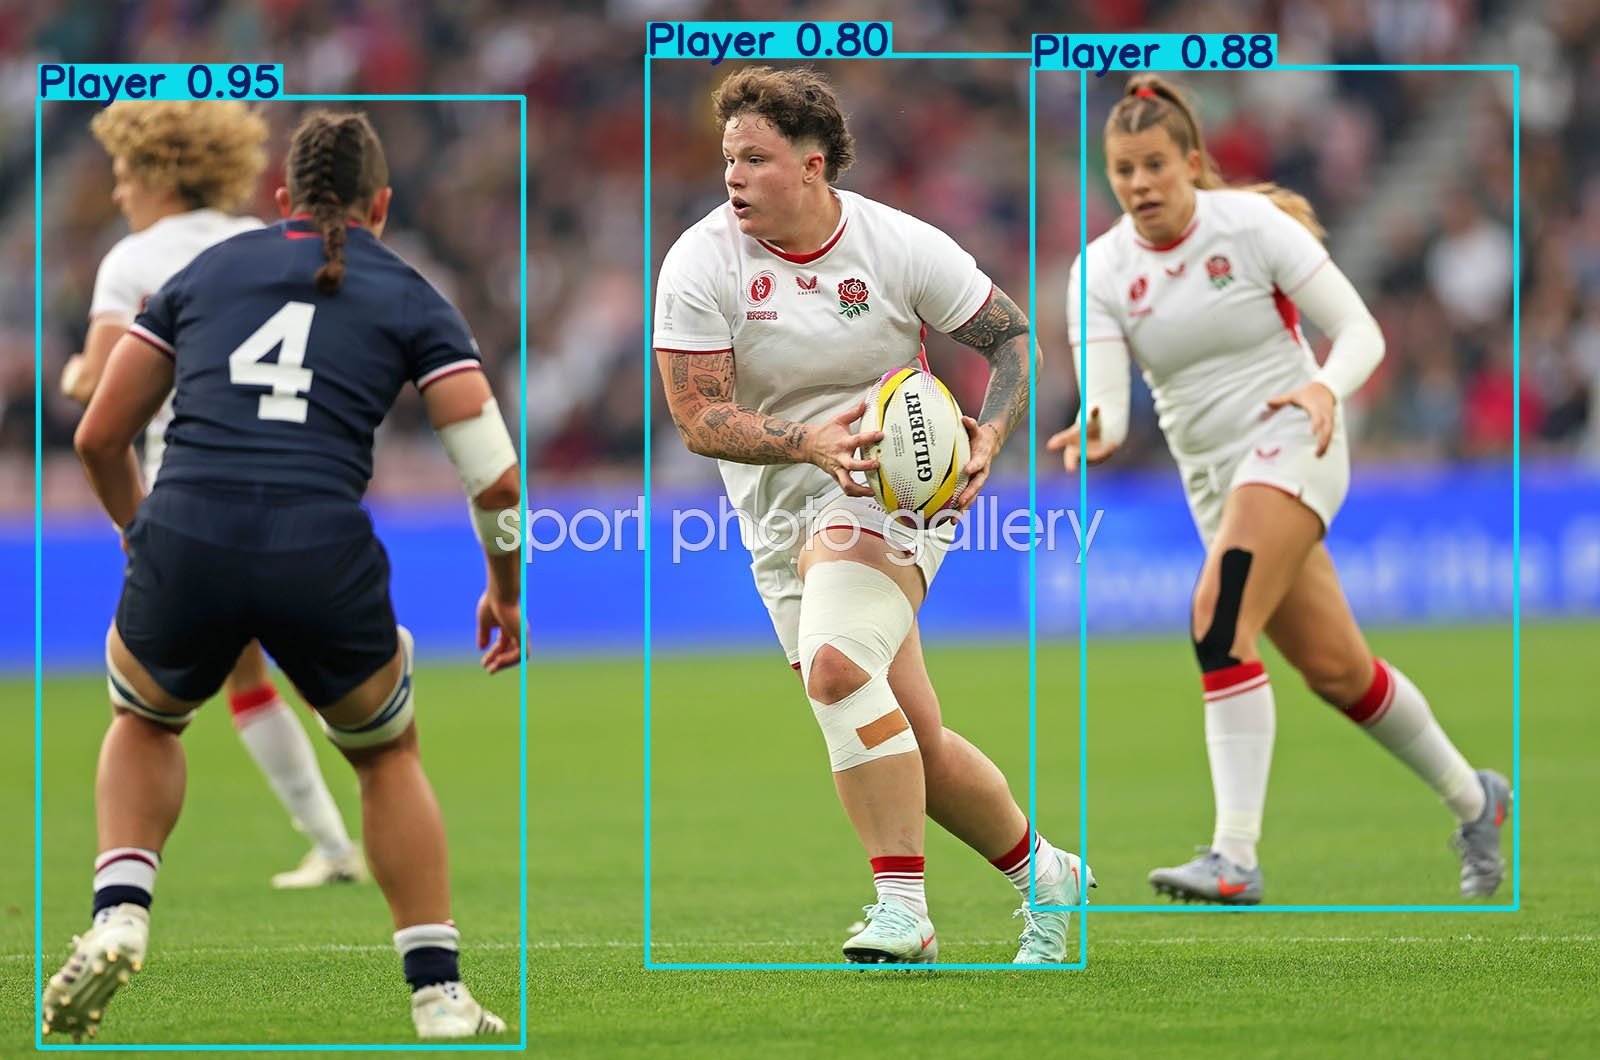

In [ ]:
from google.colab import files
from IPython.display import Image
import os
import glob

# Upload images
uploaded = files.upload()

# Test on uploaded images
for filename in uploaded.keys():
    !yolo task=detect mode=predict model=runs/detect/train/weights/best.pt source={filename} save=True

    # Find the latest prediction directory
    prediction_dirs = glob.glob('runs/detect/predict*')
    if prediction_dirs:
        latest_predict_dir = sorted(prediction_dirs)[-1]  # Get most recent
        predicted_image_path = f'{latest_predict_dir}/{filename}'

        if os.path.exists(predicted_image_path):
            print(f"Prediction for {filename}:")
            display(Image(filename=predicted_image_path, width=500))
        else:
            print(f"Predicted image not found at: {predicted_image_path}")
            print(f"Files in {latest_predict_dir}:")
            for file in os.listdir(latest_predict_dir)[:5]:  # Show first 5 files
                print(f"  - {file}")
    else:
        print("No prediction directories found")

In [ ]:
from google.colab import files
from IPython.display import HTML, Video
from base64 import b64encode
import os
import glob

# Upload video
print("Upload your video:")
uploaded = files.upload()

# Get the uploaded filename
original_filename = list(uploaded.keys())[0]
print(f"Original filename: {original_filename}")

# Create a clean filename (remove spaces and special characters)
clean_filename = "sport_video.mp4"
os.rename(original_filename, clean_filename)
print(f"Clean filename: {clean_filename}")

# Process the video with your model
!yolo task=detect mode=predict model=runs/detect/train/weights/best.pt source={clean_filename} save=True conf=0.5

# Find the processed video
prediction_dirs = glob.glob('runs/detect/predict*')
if prediction_dirs:
    latest_dir = sorted(prediction_dirs)[-1]
    print(f"Looking in: {latest_dir}")

    # Check what files were created
    print("Files in prediction directory:")
    for file in os.listdir(latest_dir):
        print(f"  - {file}")

    # Look for the output video
    video_files = glob.glob(f'{latest_dir}/*.mp4')

    if video_files:
        output_video = video_files[0]
        print(f"🎬 Success! Processed video: {output_video}")

        # Display the video
        display(Video(output_video, width=600))

        print(f"Video saved at: {output_video}")
    else:
        print("No MP4 output found. The video might still be processing or there was an error.")
else:
    print("No prediction directories found")

Upload your video:


Saving Cricket_new.mp4 to Cricket_new.mp4
Original filename: Cricket_new.mp4
Clean filename: sport_video.mp4
Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs

video 1/1 (frame 1/392) /content/sport_video.mp4: 640x384 1 Player, 51.1ms
video 1/1 (frame 2/392) /content/sport_video.mp4: 640x384 1 Player, 10.6ms
video 1/1 (frame 3/392) /content/sport_video.mp4: 640x384 1 Player, 10.6ms
video 1/1 (frame 4/392) /content/sport_video.mp4: 640x384 1 Player, 10.6ms
video 1/1 (frame 5/392) /content/sport_video.mp4: 640x384 1 Player, 10.6ms
video 1/1 (frame 6/392) /content/sport_video.mp4: 640x384 1 Player, 10.6ms
video 1/1 (frame 7/392) /content/sport_video.mp4: 640x384 1 Player, 10.6ms
video 1/1 (frame 8/392) /content/sport_video.mp4: 640x384 1 Player, 10.6ms
video 1/1 (frame 9/392) /content/sport_video.mp4: 640x384 1 Player, 10.6ms
video 1/1 (frame 10/392) /content/sport_video.mp4:

In [ ]:
from ultralytics import YOLO
import cv2

model = YOLO("yolov8n-pose.pt")

results = model("images7.jpg")

for r in results:
    img = r.plot(boxes=False)  # remove blue boxes
    cv2.imwrite("pose_only2.jpg", img)



image 1/1 /content/images7.jpg: 416x640 1 person, 10.2ms
Speed: 1.4ms preprocess, 10.2ms inference, 1.3ms postprocess per image at shape (1, 3, 416, 640)



🎨 GENERATING ALL REPORT VISUALIZATIONS

📊 Creating Training vs Validation Comparison...


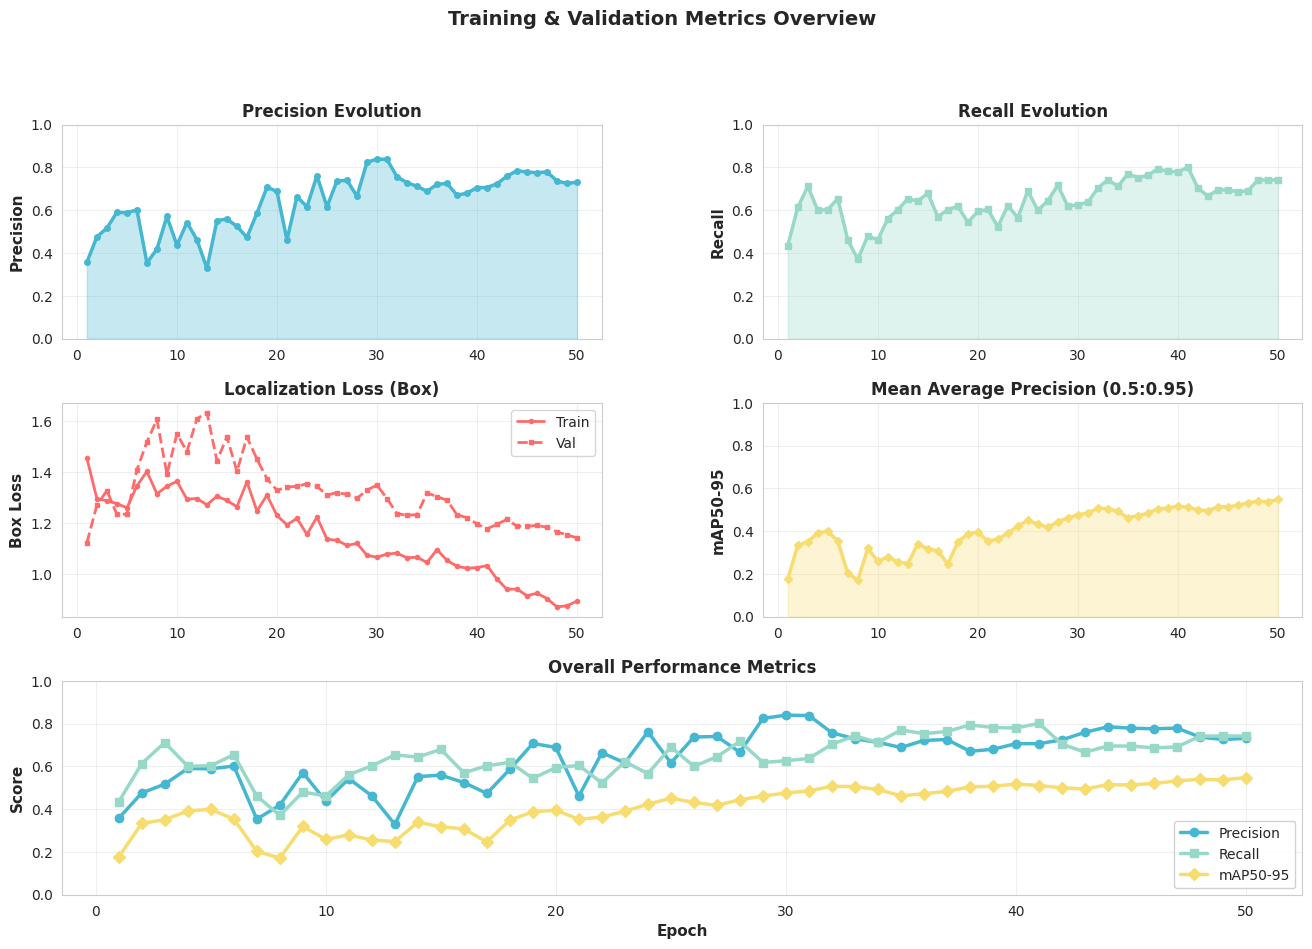

✅ Saved: 01_training_validation_comparison.png
📈 Creating Learning Curves...


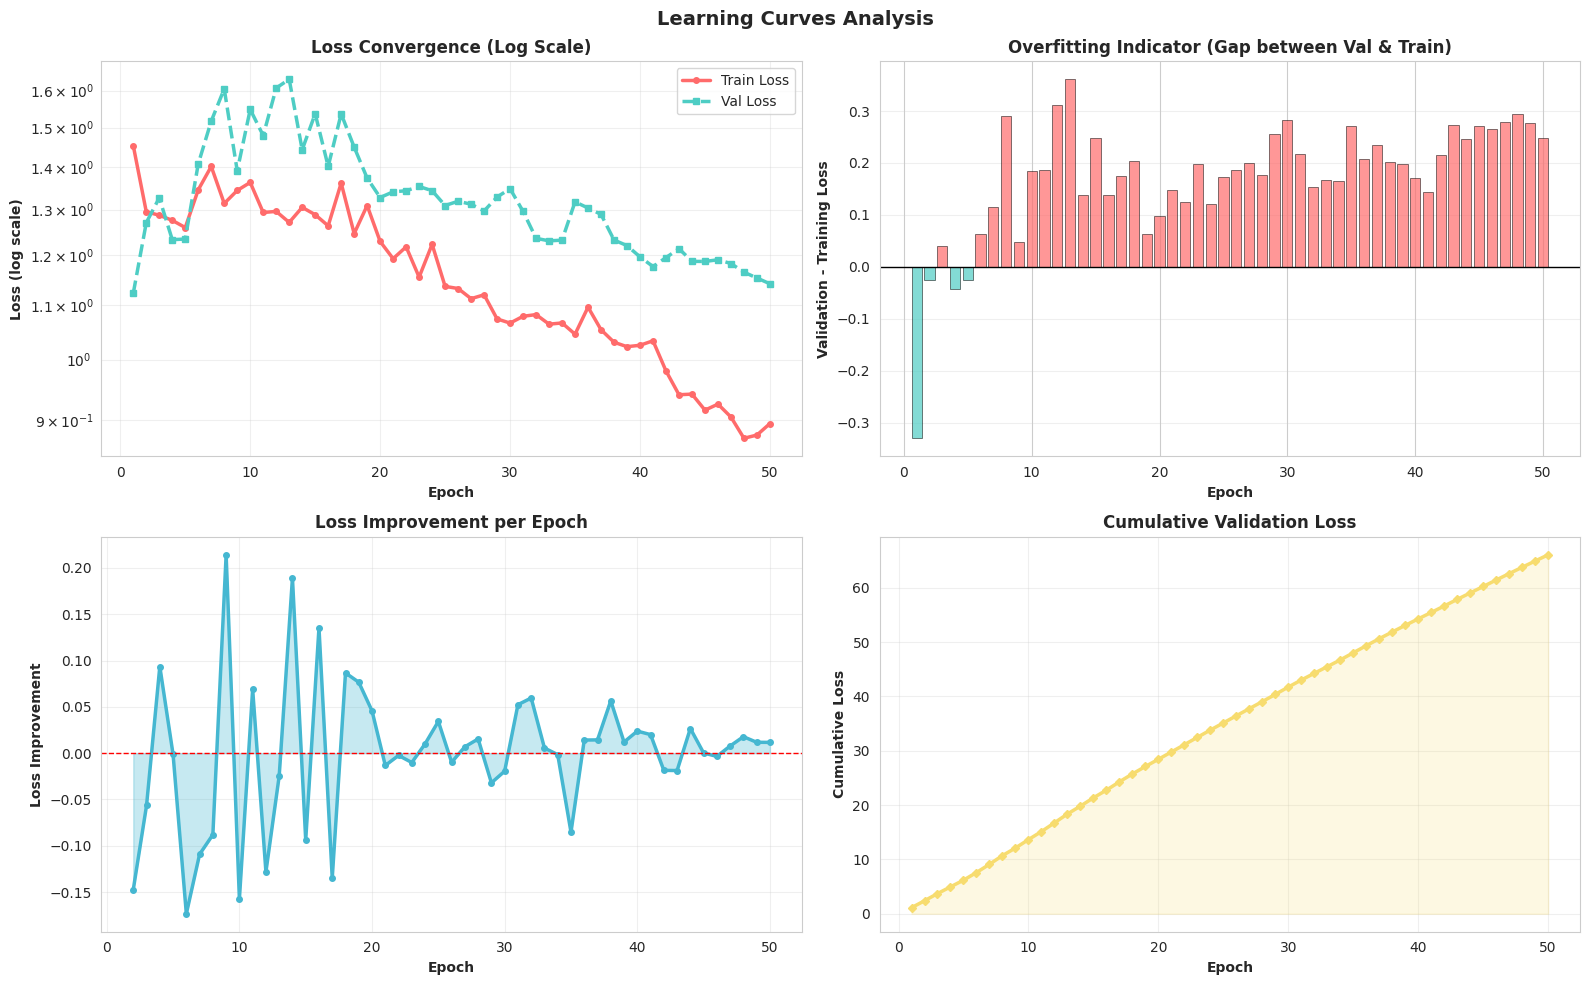

✅ Saved: 02_learning_curves.png
📋 Creating Metrics Summary Table...


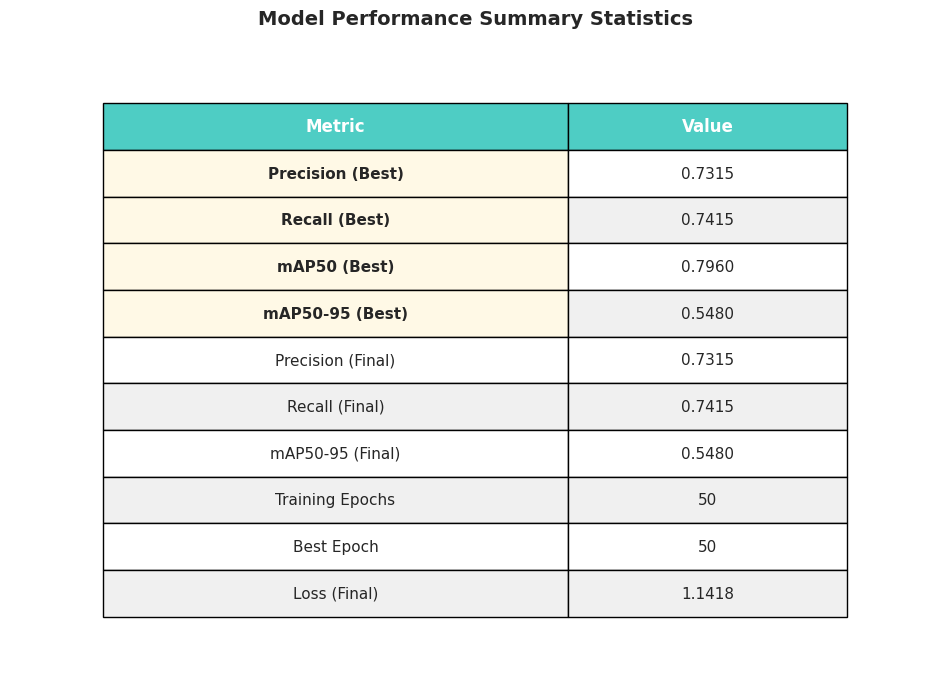

✅ Saved: 03_metrics_summary_table.png
📊 Creating Epoch-by-Epoch Improvement...


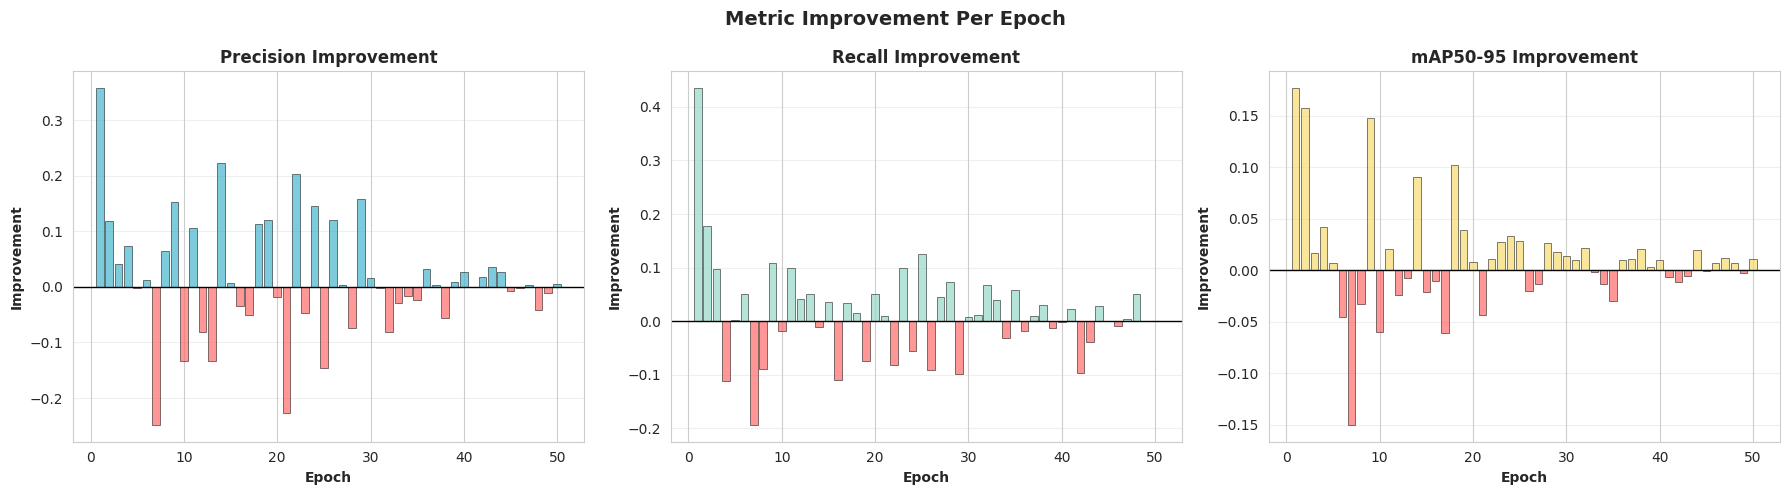

✅ Saved: 04_epoch_improvement.png
📊 Displaying YOLO Results Dashboard...


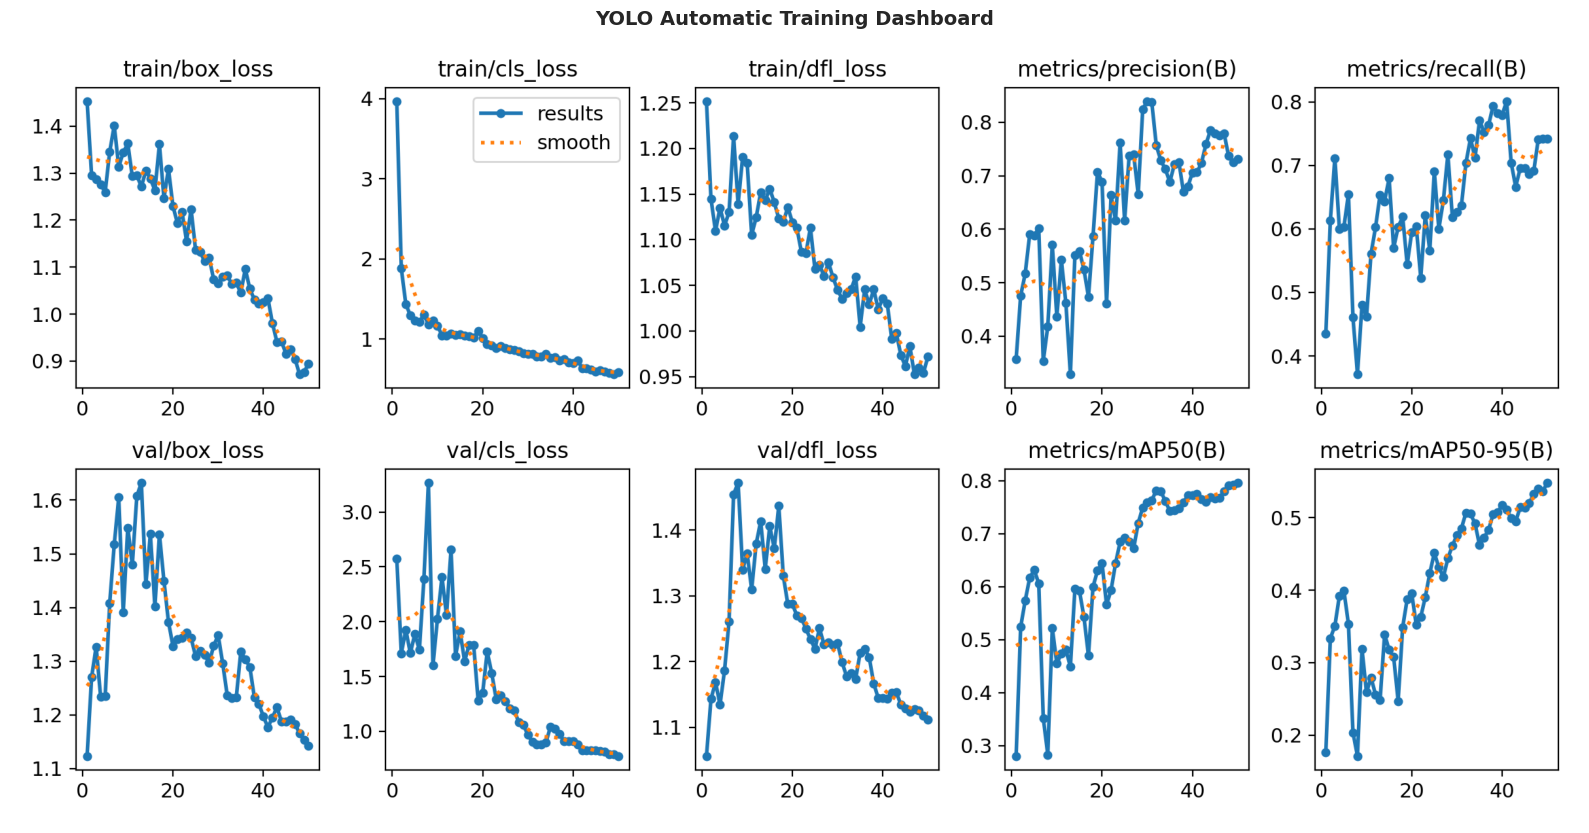

✅ Saved: 07_yolo_results_dashboard.png
🎯 Creating Confusion Matrix...


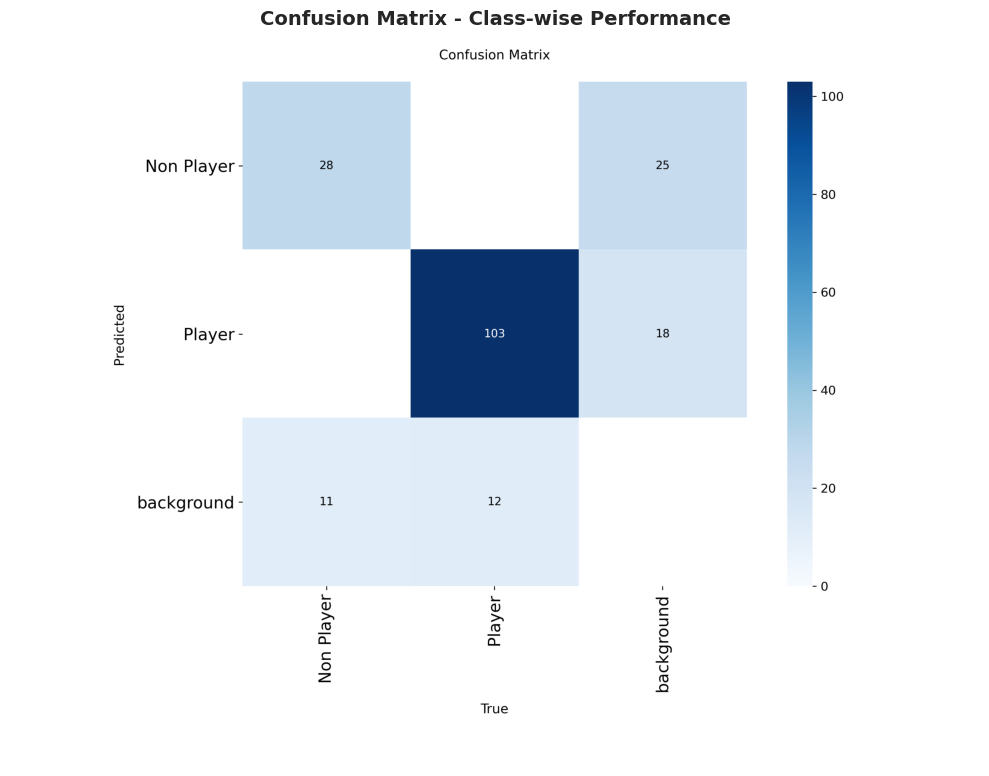

✅ Saved: 06_confusion_matrix.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2
import os
import glob

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# Read results
results_csv = 'runs/detect/train/results.csv'
results_df = pd.read_csv(results_csv)

# Helper function
def find_column(df, possible_names):
    for name in possible_names:
        if name in df.columns:
            return name
    return None

# ============================================================================
# GRAPH 1: TRAINING vs VALIDATION COMPARISON
# ============================================================================

def plot_training_validation_comparison():
    """Compare training and validation metrics side by side"""
    print("📊 Creating Training vs Validation Comparison...")

    # Find columns
    precision = find_column(results_df, ['metrics/precision(B)', 'precision'])
    recall = find_column(results_df, ['metrics/recall(B)', 'recall'])
    map50 = find_column(results_df, ['metrics/mAP50(B)', 'mAP50'])
    epoch = find_column(results_df, ['epoch', 'Epoch'])

    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

    # Row 1: Precision and Recall
    ax1 = fig.add_subplot(gs[0, 0])
    if precision:
        ax1.fill_between(results_df[epoch], results_df[precision], alpha=0.3, color='#45B7D1')
        ax1.plot(results_df[epoch], results_df[precision], linewidth=2.5, color='#45B7D1', marker='o', markersize=4)
        ax1.set_ylabel('Precision', fontweight='bold', fontsize=11)
        ax1.set_title('Precision Evolution', fontweight='bold', fontsize=12)
        ax1.grid(alpha=0.3)
        ax1.set_ylim([0, 1])

    ax2 = fig.add_subplot(gs[0, 1])
    if recall:
        ax2.fill_between(results_df[epoch], results_df[recall], alpha=0.3, color='#98D8C8')
        ax2.plot(results_df[epoch], results_df[recall], linewidth=2.5, color='#98D8C8', marker='s', markersize=4)
        ax2.set_ylabel('Recall', fontweight='bold', fontsize=11)
        ax2.set_title('Recall Evolution', fontweight='bold', fontsize=12)
        ax2.grid(alpha=0.3)
        ax2.set_ylim([0, 1])

    # Row 2: Loss components
    ax3 = fig.add_subplot(gs[1, 0])
    box_loss_train = find_column(results_df, ['train/box_loss', 'train_loss/box_loss'])
    box_loss_val = find_column(results_df, ['val/box_loss', 'val_loss/box_loss'])
    if box_loss_train and box_loss_val:
        ax3.plot(results_df[epoch], results_df[box_loss_train], linewidth=2, color='#FF6B6B', label='Train', marker='o', markersize=3)
        ax3.plot(results_df[epoch], results_df[box_loss_val], linewidth=2, color='#FF6B6B', linestyle='--', label='Val', marker='s', markersize=3)
        ax3.set_ylabel('Box Loss', fontweight='bold', fontsize=11)
        ax3.set_title('Localization Loss (Box)', fontweight='bold', fontsize=12)
        ax3.legend(loc='upper right', fontsize=10)
        ax3.grid(alpha=0.3)

    ax4 = fig.add_subplot(gs[1, 1])
    map50_95 = find_column(results_df, ['metrics/mAP50-95(B)', 'mAP50-95'])
    if map50_95:
        ax4.fill_between(results_df[epoch], results_df[map50_95], alpha=0.3, color='#F7DC6F')
        ax4.plot(results_df[epoch], results_df[map50_95], linewidth=2.5, color='#F7DC6F', marker='D', markersize=4)
        ax4.set_ylabel('mAP50-95', fontweight='bold', fontsize=11)
        ax4.set_title('Mean Average Precision (0.5:0.95)', fontweight='bold', fontsize=12)
        ax4.grid(alpha=0.3)
        ax4.set_ylim([0, 1])

    # Row 3: All metrics together
    ax5 = fig.add_subplot(gs[2, :])
    if precision and recall and map50_95:
        ax5.plot(results_df[epoch], results_df[precision], linewidth=2.5, label='Precision', color='#45B7D1', marker='o')
        ax5.plot(results_df[epoch], results_df[recall], linewidth=2.5, label='Recall', color='#98D8C8', marker='s')
        ax5.plot(results_df[epoch], results_df[map50_95], linewidth=2.5, label='mAP50-95', color='#F7DC6F', marker='D')
        ax5.set_xlabel('Epoch', fontweight='bold', fontsize=11)
        ax5.set_ylabel('Score', fontweight='bold', fontsize=11)
        ax5.set_title('Overall Performance Metrics', fontweight='bold', fontsize=12)
        ax5.legend(loc='lower right', fontsize=10, framealpha=0.9)
        ax5.grid(alpha=0.3)
        ax5.set_ylim([0, 1])

    plt.suptitle('Training & Validation Metrics Overview', fontsize=14, fontweight='bold', y=0.995)
    plt.savefig('01_training_validation_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Saved: 01_training_validation_comparison.png")

# ============================================================================
# GRAPH 2: LEARNING CURVES
# ============================================================================

def plot_learning_curves():
    """Advanced learning curves with trend lines"""
    print("📈 Creating Learning Curves...")

    epoch = find_column(results_df, ['epoch', 'Epoch'])
    box_loss_train = find_column(results_df, ['train/box_loss', 'train_loss/box_loss'])
    box_loss_val = find_column(results_df, ['val/box_loss', 'val_loss/box_loss'])

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Learning Curves Analysis', fontsize=14, fontweight='bold')

    # Loss on log scale
    ax = axes[0, 0]
    if box_loss_train and box_loss_val:
        ax.semilogy(results_df[epoch], results_df[box_loss_train], 'o-', label='Train Loss', linewidth=2.5, markersize=4, color='#FF6B6B')
        ax.semilogy(results_df[epoch], results_df[box_loss_val], 's--', label='Val Loss', linewidth=2.5, markersize=4, color='#4ECDC4')
        ax.set_xlabel('Epoch', fontweight='bold')
        ax.set_ylabel('Loss (log scale)', fontweight='bold')
        ax.set_title('Loss Convergence (Log Scale)', fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3, which='both')

    # Loss difference (overfitting indicator)
    ax = axes[0, 1]
    if box_loss_train and box_loss_val:
        loss_diff = results_df[box_loss_val] - results_df[box_loss_train]
        colors = ['#FF6B6B' if x > 0 else '#4ECDC4' for x in loss_diff]
        ax.bar(results_df[epoch], loss_diff, color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)
        ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
        ax.set_xlabel('Epoch', fontweight='bold')
        ax.set_ylabel('Validation - Training Loss', fontweight='bold')
        ax.set_title('Overfitting Indicator (Gap between Val & Train)', fontweight='bold')
        ax.grid(alpha=0.3, axis='y')

    # Loss improvement per epoch
    ax = axes[1, 0]
    if box_loss_val:
        loss_improvement = -np.diff(results_df[box_loss_val])
        ax.fill_between(results_df[epoch][1:], loss_improvement, alpha=0.3, color='#45B7D1')
        ax.plot(results_df[epoch][1:], loss_improvement, 'o-', linewidth=2.5, color='#45B7D1', markersize=4)
        ax.axhline(y=0, color='red', linestyle='--', linewidth=1)
        ax.set_xlabel('Epoch', fontweight='bold')
        ax.set_ylabel('Loss Improvement', fontweight='bold')
        ax.set_title('Loss Improvement per Epoch', fontweight='bold')
        ax.grid(alpha=0.3)

    # Cumulative loss
    ax = axes[1, 1]
    if box_loss_val:
        cumulative_loss = np.cumsum(results_df[box_loss_val])
        ax.plot(results_df[epoch], cumulative_loss, 'D-', linewidth=2.5, color='#F7DC6F', markersize=4)
        ax.fill_between(results_df[epoch], cumulative_loss, alpha=0.2, color='#F7DC6F')
        ax.set_xlabel('Epoch', fontweight='bold')
        ax.set_ylabel('Cumulative Loss', fontweight='bold')
        ax.set_title('Cumulative Validation Loss', fontweight='bold')
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('02_learning_curves.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Saved: 02_learning_curves.png")

# ============================================================================
# GRAPH 3: METRIC SUMMARY TABLE & STATISTICS
# ============================================================================

def plot_metrics_summary():
    """Create a beautiful metrics summary table"""
    print("📋 Creating Metrics Summary Table...")

    epoch = find_column(results_df, ['epoch', 'Epoch'])
    precision = find_column(results_df, ['metrics/precision(B)', 'precision'])
    recall = find_column(results_df, ['metrics/recall(B)', 'recall'])
    map50 = find_column(results_df, ['metrics/mAP50(B)', 'mAP50'])
    map50_95 = find_column(results_df, ['metrics/mAP50-95(B)', 'mAP50-95'])
    box_loss_val = find_column(results_df, ['val/box_loss', 'val_loss/box_loss'])

    # Calculate statistics
    if map50_95:
        best_epoch_idx = results_df[map50_95].idxmax()
        best_epoch_num = int(results_df.iloc[best_epoch_idx][epoch])

        stats = {
            'Metric': [
                'Precision (Best)',
                'Recall (Best)',
                'mAP50 (Best)',
                'mAP50-95 (Best)',
                'Precision (Final)',
                'Recall (Final)',
                'mAP50-95 (Final)',
                'Training Epochs',
                'Best Epoch',
                'Loss (Final)'
            ],
            'Value': [
                f"{results_df.iloc[best_epoch_idx][precision]:.4f}" if precision else "N/A",
                f"{results_df.iloc[best_epoch_idx][recall]:.4f}" if recall else "N/A",
                f"{results_df.iloc[best_epoch_idx][map50]:.4f}" if map50 else "N/A",
                f"{results_df.iloc[best_epoch_idx][map50_95]:.4f}" if map50_95 else "N/A",
                f"{results_df.iloc[-1][precision]:.4f}" if precision else "N/A",
                f"{results_df.iloc[-1][recall]:.4f}" if recall else "N/A",
                f"{results_df.iloc[-1][map50_95]:.4f}" if map50_95 else "N/A",
                f"{len(results_df)}",
                f"{best_epoch_num}",
                f"{results_df.iloc[-1][box_loss_val]:.4f}" if box_loss_val else "N/A"
            ]
        }

        stats_df = pd.DataFrame(stats)

        fig, ax = plt.subplots(figsize=(12, 8))
        ax.axis('tight')
        ax.axis('off')

        table = ax.table(cellText=stats_df.values,
                        colLabels=stats_df.columns,
                        cellLoc='center',
                        loc='center',
                        colWidths=[0.5, 0.3])

        table.auto_set_font_size(False)
        table.set_fontsize(11)
        table.scale(1, 2.8)

        # Style header
        for i in range(len(stats_df.columns)):
            table[(0, i)].set_facecolor('#4ECDC4')
            table[(0, i)].set_text_props(weight='bold', color='white', fontsize=12)

        # Alternate row colors
        for i in range(1, len(stats_df) + 1):
            for j in range(len(stats_df.columns)):
                if i % 2 == 0:
                    table[(i, j)].set_facecolor('#F0F0F0')
                if i <= 4:  # Highlight best metrics
                    table[(i, 0)].set_facecolor('#FFF9E6')
                    table[(i, 0)].set_text_props(weight='bold')

        plt.title('Model Performance Summary Statistics', fontsize=14, fontweight='bold', pad=20)
        plt.savefig('03_metrics_summary_table.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("✅ Saved: 03_metrics_summary_table.png")

# ============================================================================
# GRAPH 4: EPOCH-BY-EPOCH IMPROVEMENT
# ============================================================================

def plot_epoch_improvement():
    """Show improvement metrics for each epoch"""
    print("📊 Creating Epoch-by-Epoch Improvement...")

    epoch = find_column(results_df, ['epoch', 'Epoch'])
    precision = find_column(results_df, ['metrics/precision(B)', 'precision'])
    recall = find_column(results_df, ['metrics/recall(B)', 'recall'])
    map50_95 = find_column(results_df, ['metrics/mAP50-95(B)', 'mAP50-95'])

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Metric Improvement Per Epoch', fontsize=14, fontweight='bold')

    if precision:
        improvement = np.diff([0] + list(results_df[precision]))
        colors = ['#45B7D1' if x > 0 else '#FF6B6B' for x in improvement]
        axes[0].bar(results_df[epoch], improvement, color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)
        axes[0].axhline(y=0, color='black', linestyle='-', linewidth=1)
        axes[0].set_ylabel('Improvement', fontweight='bold')
        axes[0].set_xlabel('Epoch', fontweight='bold')
        axes[0].set_title('Precision Improvement', fontweight='bold')
        axes[0].grid(alpha=0.3, axis='y')

    if recall:
        improvement = np.diff([0] + list(results_df[recall]))
        colors = ['#98D8C8' if x > 0 else '#FF6B6B' for x in improvement]
        axes[1].bar(results_df[epoch], improvement, color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)
        axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1)
        axes[1].set_ylabel('Improvement', fontweight='bold')
        axes[1].set_xlabel('Epoch', fontweight='bold')
        axes[1].set_title('Recall Improvement', fontweight='bold')
        axes[1].grid(alpha=0.3, axis='y')

    if map50_95:
        improvement = np.diff([0] + list(results_df[map50_95]))
        colors = ['#F7DC6F' if x > 0 else '#FF6B6B' for x in improvement]
        axes[2].bar(results_df[epoch], improvement, color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)
        axes[2].axhline(y=0, color='black', linestyle='-', linewidth=1)
        axes[2].set_ylabel('Improvement', fontweight='bold')
        axes[2].set_xlabel('Epoch', fontweight='bold')
        axes[2].set_title('mAP50-95 Improvement', fontweight='bold')
        axes[2].grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('04_epoch_improvement.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Saved: 04_epoch_improvement.png")


# ============================================================================
# GRAPH 5: CONFUSION MATRIX
# ============================================================================

def plot_confusion_matrix():
    """Plot confusion matrix from results"""
    print("🎯 Creating Confusion Matrix...")

    confusion_path = 'runs/detect/train/confusion_matrix.png'

    if os.path.exists(confusion_path):
        fig, ax = plt.subplots(figsize=(10, 8))
        img = cv2.imread(confusion_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.axis('off')
        plt.title('Confusion Matrix - Class-wise Performance', fontsize=14, fontweight='bold', pad=10)
        plt.tight_layout()
        plt.savefig('06_confusion_matrix.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("✅ Saved: 06_confusion_matrix.png")
    else:
        print("⚠️  Confusion matrix not found in training results")

# ============================================================================
# GRAPH 6: RESULTS.PNG FROM YOLO
# ============================================================================

def display_yolo_results():
    """Display the automatic results.png from YOLO training"""
    print("📊 Displaying YOLO Results Dashboard...")

    results_path = 'runs/detect/train/results.png'

    if os.path.exists(results_path):
        fig, ax = plt.subplots(figsize=(16, 10))
        img = cv2.imread(results_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.axis('off')
        plt.title('YOLO Automatic Training Dashboard', fontsize=14, fontweight='bold', pad=10)
        plt.tight_layout()
        plt.savefig('07_yolo_results_dashboard.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("✅ Saved: 07_yolo_results_dashboard.png")
    else:
        print("⚠️  results.png not found")


# ============================================================================
# RUN ALL VISUALIZATIONS
# ============================================================================

if __name__ == "__main__":
    print("\n" + "="*70)
    print("🎨 GENERATING ALL REPORT VISUALIZATIONS")
    print("="*70 + "\n")

    plot_training_validation_comparison()
    plot_learning_curves()
    plot_metrics_summary()
    plot_epoch_improvement()
    display_yolo_results()
    plot_confusion_matrix()


